# 

In [4]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("06-study_hours_grades.csv")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [7]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [8]:
# data
# build a model
# prediction with model
# evaulation
# improvement
# save the model

In [9]:
df.describe() #data hakkında bilgiler

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [10]:
df["study_hours"].values

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

In [11]:
torch.tensor(df["study_hours"].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [12]:
y=torch.tensor(df["grade"].values)
X=torch.tensor(df["study_hours"].values)

In [13]:
# train - test split

In [14]:
int(len(X))

50

In [15]:
train_split= int(len(X)*0.8)
X_train, y_train= X[:train_split], y[:train_split]
X_test, y_test= X[train_split:], y[train_split:]

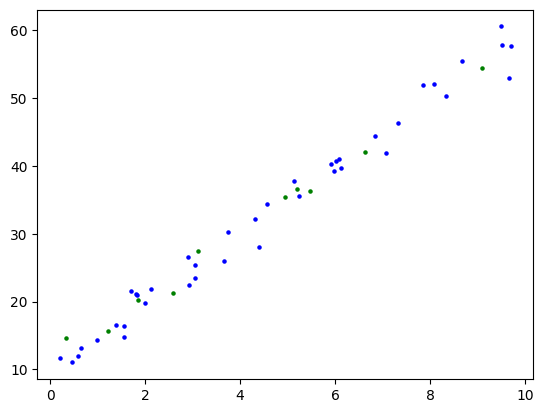

In [16]:
plt.scatter(X_train, y_train, c="b", s=5, label= "Training Data")
plt.scatter(X_test, y_test, c="g", s=5, label= "Test Data")

In [17]:
# pytorch ann

In [18]:
from torch import nn

class SimpleLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
         # requires_grad öğrenebilir bir parametre mi diye sorar evetse True
        self.weights= nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias= nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor)->torch.Tensor:
        return self.weights * x + self.bias

In [79]:
torch.manual_seed(42)
model_0= SimpleLinearRegressionModel()
#model_0= torch.compile(model_0) # model'i optimize ederek daha hızlı train edilmesini sağlıyor.


In [80]:
model_0.state_dict() # O anki durumu sözlük halinde gösterir.

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [81]:
with torch.inference_mode(): # Tahmin etme -> Buraya X_test verilir y_test tahmin edilir
    y_pred=(model_0(X_test))
    
    
    

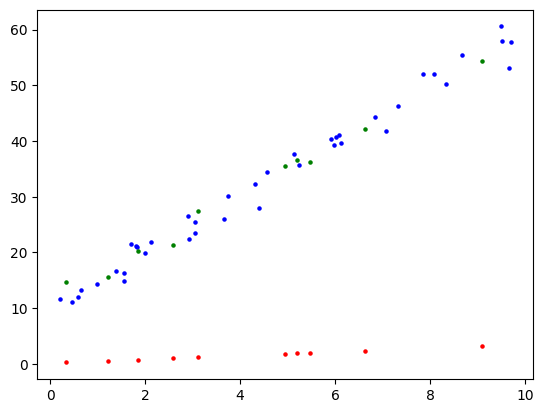

In [82]:
plt.scatter(X_train, y_train, c="b", s=5, label= "Training Data")
plt.scatter(X_test, y_test, c="g", s=5, label= "Test Data")
plt.scatter(X_test, y_pred, c="r", s=5, label= "Prediction Data")


In [83]:
loss_fn=nn.MSELoss()
optimizer= torch.optim.SGD(params=model_0.parameters(), lr=0.001)

In [84]:
torch.manual_seed(42)

epochs = 60
train_loss_values=[]
test_loss_values=[]
epoch_count= []

for epoch in range(epochs):
    #train mode
    model_0.train() 
    #prediction
    y_pred= model_0(X_train)
    #loss calculation
    loss= loss_fn(y_pred, y_train)
    #back prop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    #evaulation değerlendirme modu
    model_0.eval()# test modu
    #eğitimi test etme
    with torch.inference_mode():
        test_pred= model_0(X_test)
        test_loss= loss_fn(test_pred, y_test) #loss_fn(test_pred, y_test.type(torch.float)

        if epoch %5==0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")
            
            

    


Epoch: 0, Train Loss: 1156.0767463081781, Test Loss: 858.3088765088272
Epoch: 5, Train Loss: 633.9334744710083, Test Loss: 484.2837829868178
Epoch: 10, Train Loss: 352.99125276114285, Test Loss: 280.90521005460033
Epoch: 15, Train Loss: 201.80191856738534, Test Loss: 169.8918797355706
Epoch: 20, Train Loss: 120.41268871324436, Test Loss: 108.98031233032034
Epoch: 25, Train Loss: 76.57232180621143, Test Loss: 75.32370882849361
Epoch: 30, Train Loss: 52.931428428694815, Test Loss: 56.55033419714631
Epoch: 35, Train Loss: 40.157054153236494, Test Loss: 45.9453113422317
Epoch: 40, Train Loss: 33.22852214719357, Test Loss: 39.85290344471839
Epoch: 45, Train Loss: 29.44508410079029, Test Loss: 36.274774134597365
Epoch: 50, Train Loss: 27.353844189863754, Test Loss: 34.11265188608324
Epoch: 55, Train Loss: 26.173217192098285, Test Loss: 32.75872353470674


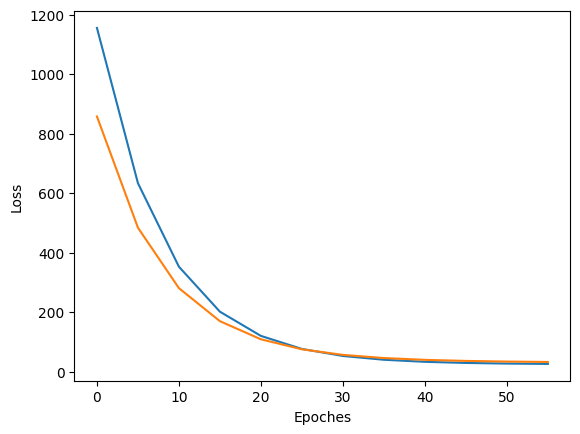

In [85]:
plt.plot(epoch_count, train_loss_values, label= "Train Loss")
plt.plot(epoch_count, test_loss_values, label= "Test Loss")
plt.ylabel("Loss")
plt.xlabel("Epoches")
plt.show()

In [86]:
model_0.state_dict()

OrderedDict([('weights', tensor([6.2000])), ('bias', tensor([1.3524]))])

In [87]:
model_0.eval()
with torch.inference_mode():
    y_preds= model_0(X_test)

In [88]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [89]:
y_preds

tensor([ 8.9188, 32.0533,  3.4845, 57.7301, 17.3967, 42.4287, 20.6784, 33.5965,
        35.2483, 12.8134], dtype=torch.float64)

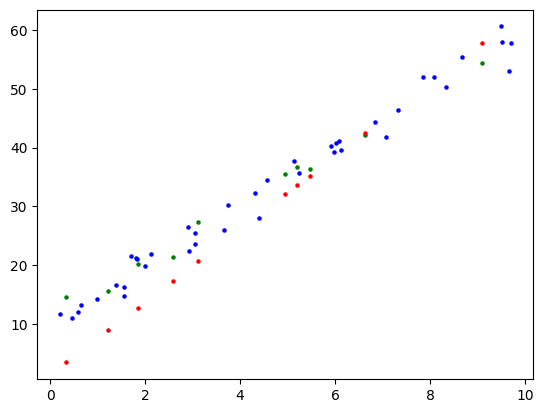

In [90]:
plt.scatter(X_train, y_train, c="b", s=5, label= "Training Data")
plt.scatter(X_test, y_test, c="g", s=5, label= "Test Data")
plt.scatter(X_test, y_preds, c="r", s=5, label= "Prediction Data")
